# code to create video-recall event match matrices (Figure _?_)

### imports

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from itertools import zip_longest
from os.path import join as opj
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
%matplotlib inline

In [2]:
# try to show progress bars for long-running cells
# to properly show progress bars, you'll need to install tqdm,
# as well as widgetsnbextension and ipywidgets to render the element
try:
    from tqdm import tqdm_notebook as tqdm
    show_pbar = True
except ModuleNotFoundError:
    print('To enable progress bars, install tqdm module (`pip install tqdm`)')
    show_pbar = False

### set paths

In [3]:
data_dir = '../../data'
ep_events_dir = opj(data_dir, 'models', 'episodes', 'events')
rec_events_dir = opj(data_dir, 'models', 'recalls', 'events')
pickle_dir = opj(data_dir, 'pickles')

# create output folder for matchmat figures
matchmats_dir = '../../paper/figures/matchmats'
if not os.path.isdir(matchmats_dir):
    os.mkdir(matchmats_dir)

### load data

In [4]:
# episode events
episode_events = {episode : np.load(opj(ep_events_dir, f'{episode}_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# recall events
recall_events = {rectype : {} for rectype in ['atlep1', 'prediction', 'delayed', 'atlep2', 'arrdev']}
for rectype in recall_events.keys():
    rt_dir = opj(rec_events_dir, rectype)
    for file in [f for f in os.listdir(rt_dir) if f.startswith('debug')]:
        recall_events[rectype][os.path.splitext(file)[0]] = np.load(opj(rt_dir, file))
        
# episode-recall event mappings
event_mappings = {rectype : np.load(opj(rec_events_dir, rectype, 'event_mappings.npy'), allow_pickle=True)
                  for rectype in recall_events.keys()}

# across-session ID mapppings
with open(opj(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## compute episode-recall event matrices

In [5]:
matchmats = {rectype : {} for rectype in recall_events.keys()}

for rectype, data in recall_events.items():
    if rectype == 'delayed':
        ep_events = episode_events['atlep1']
    elif rectype == 'prediction':
        ep_events = episode_events['atlep2']
    else:
        ep_events = episode_events[rectype]
        
    matchmats[rectype] = {turkid : 1-cdist(ep_events, rec_events, 'correlation') 
                          for turkid, rec_events in data.items()}

## plot

In [6]:
# plot params
cmap = plt.cm.bone_r
sns.set_context('talk')

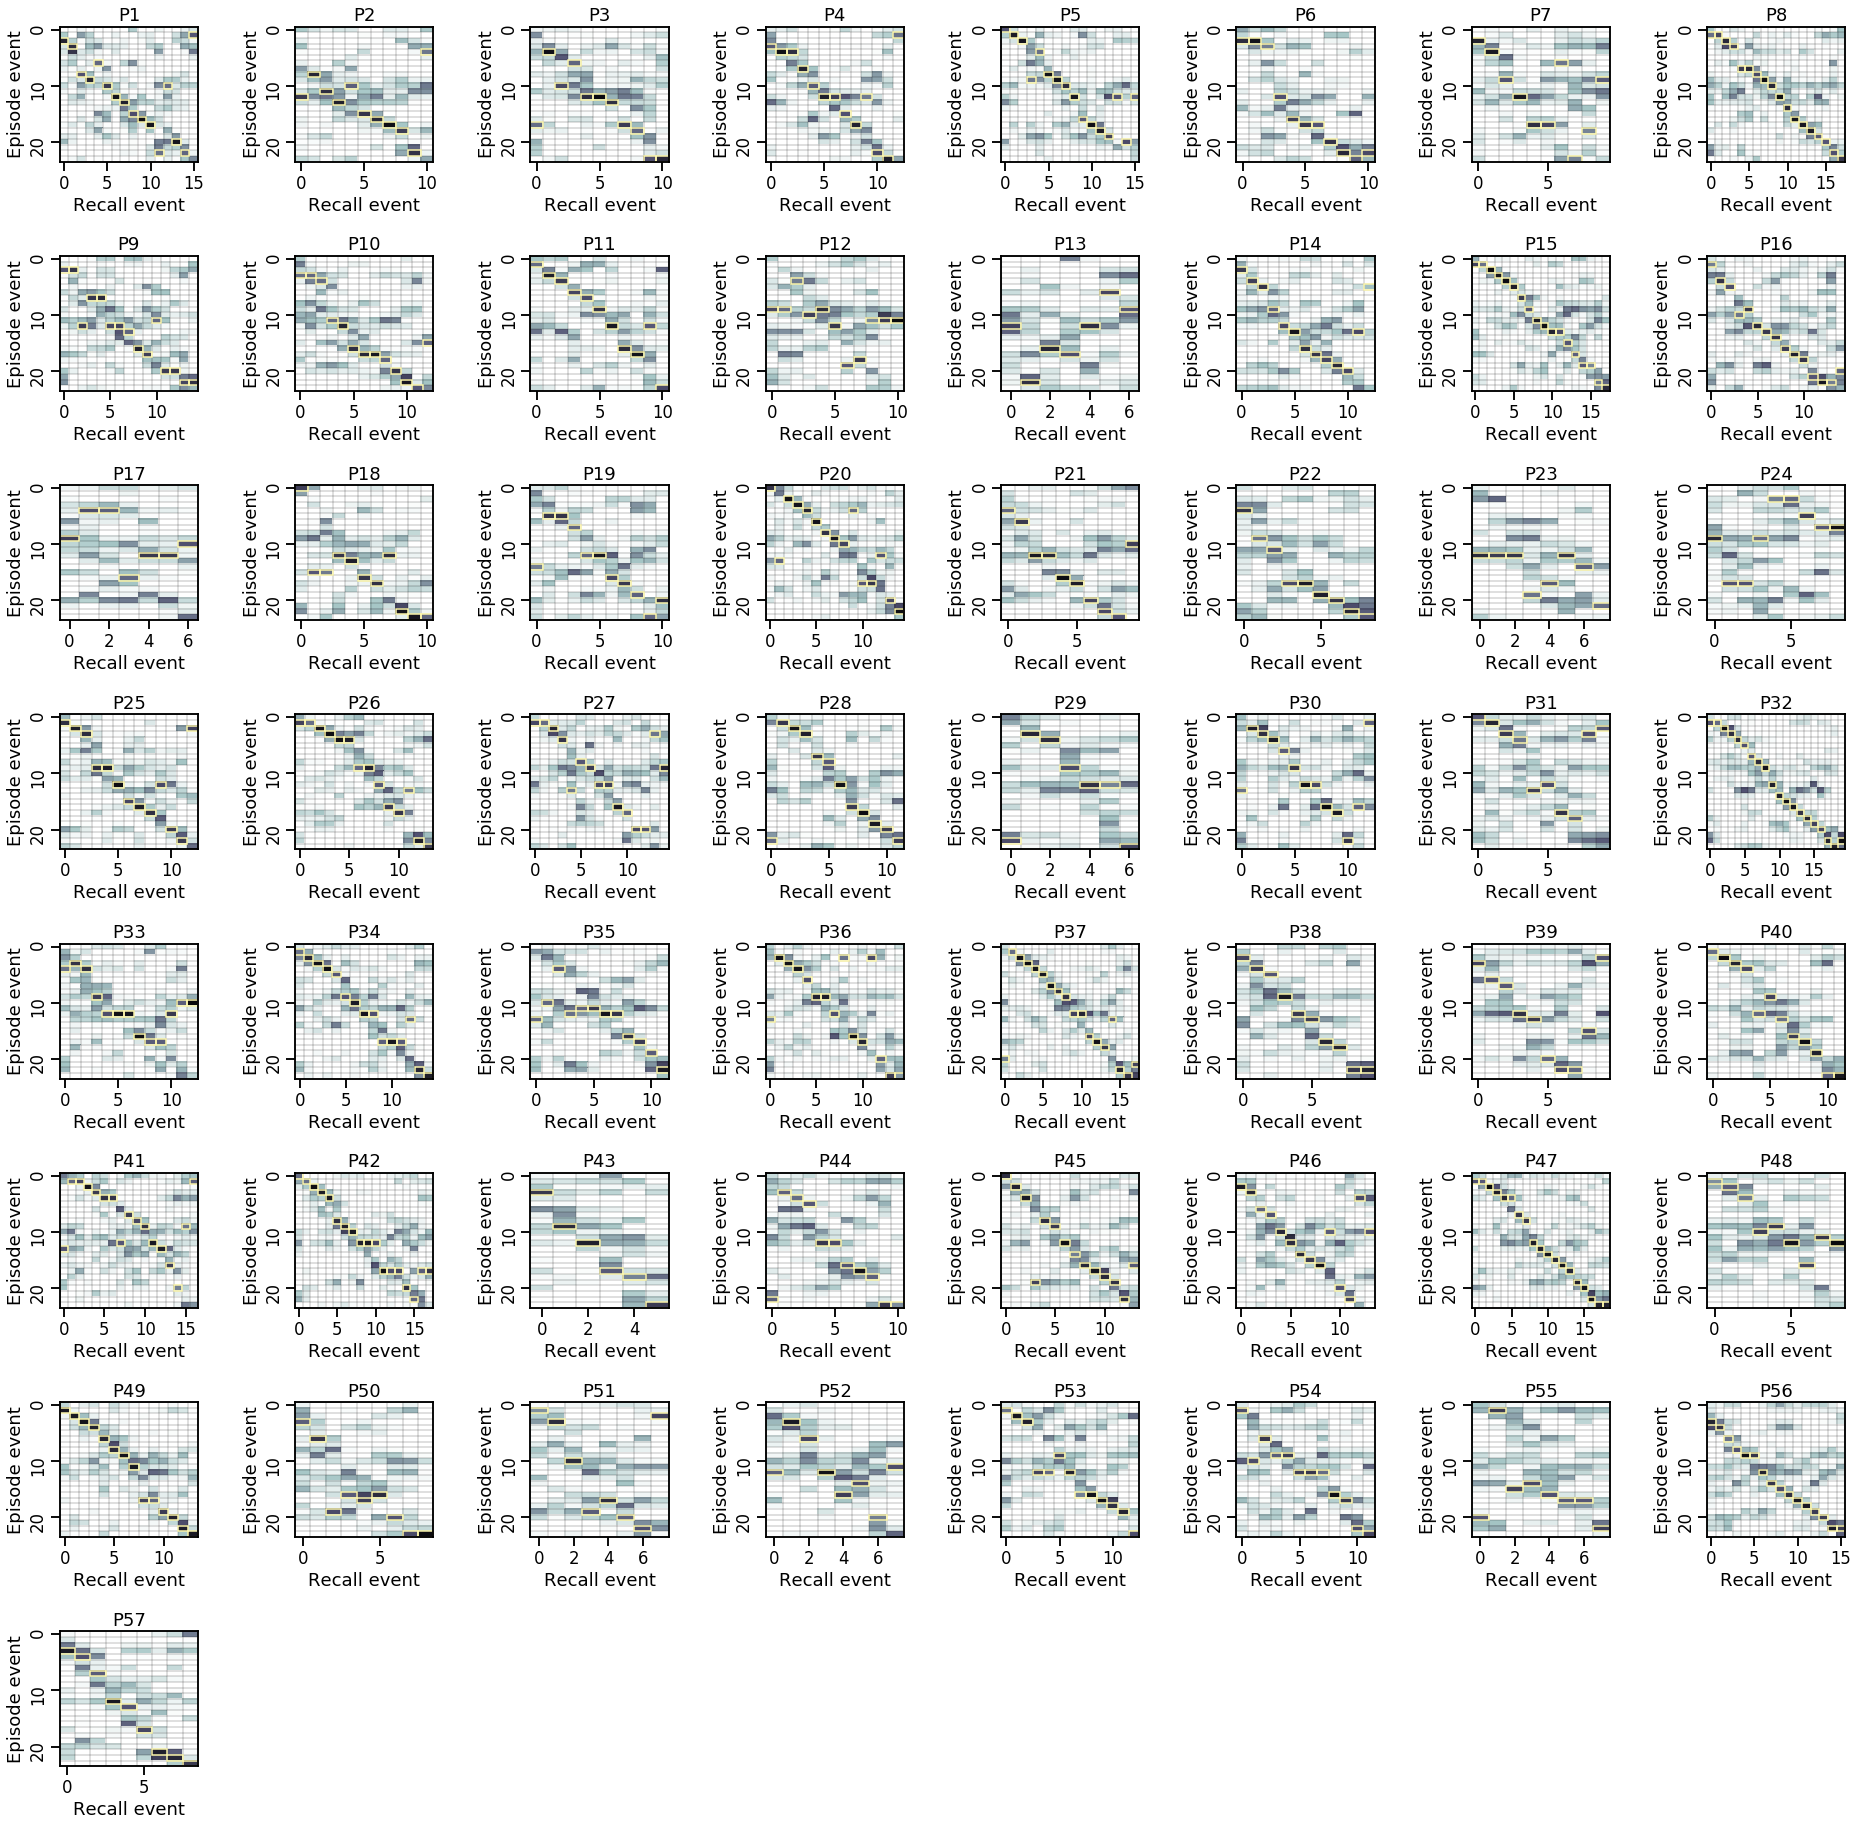

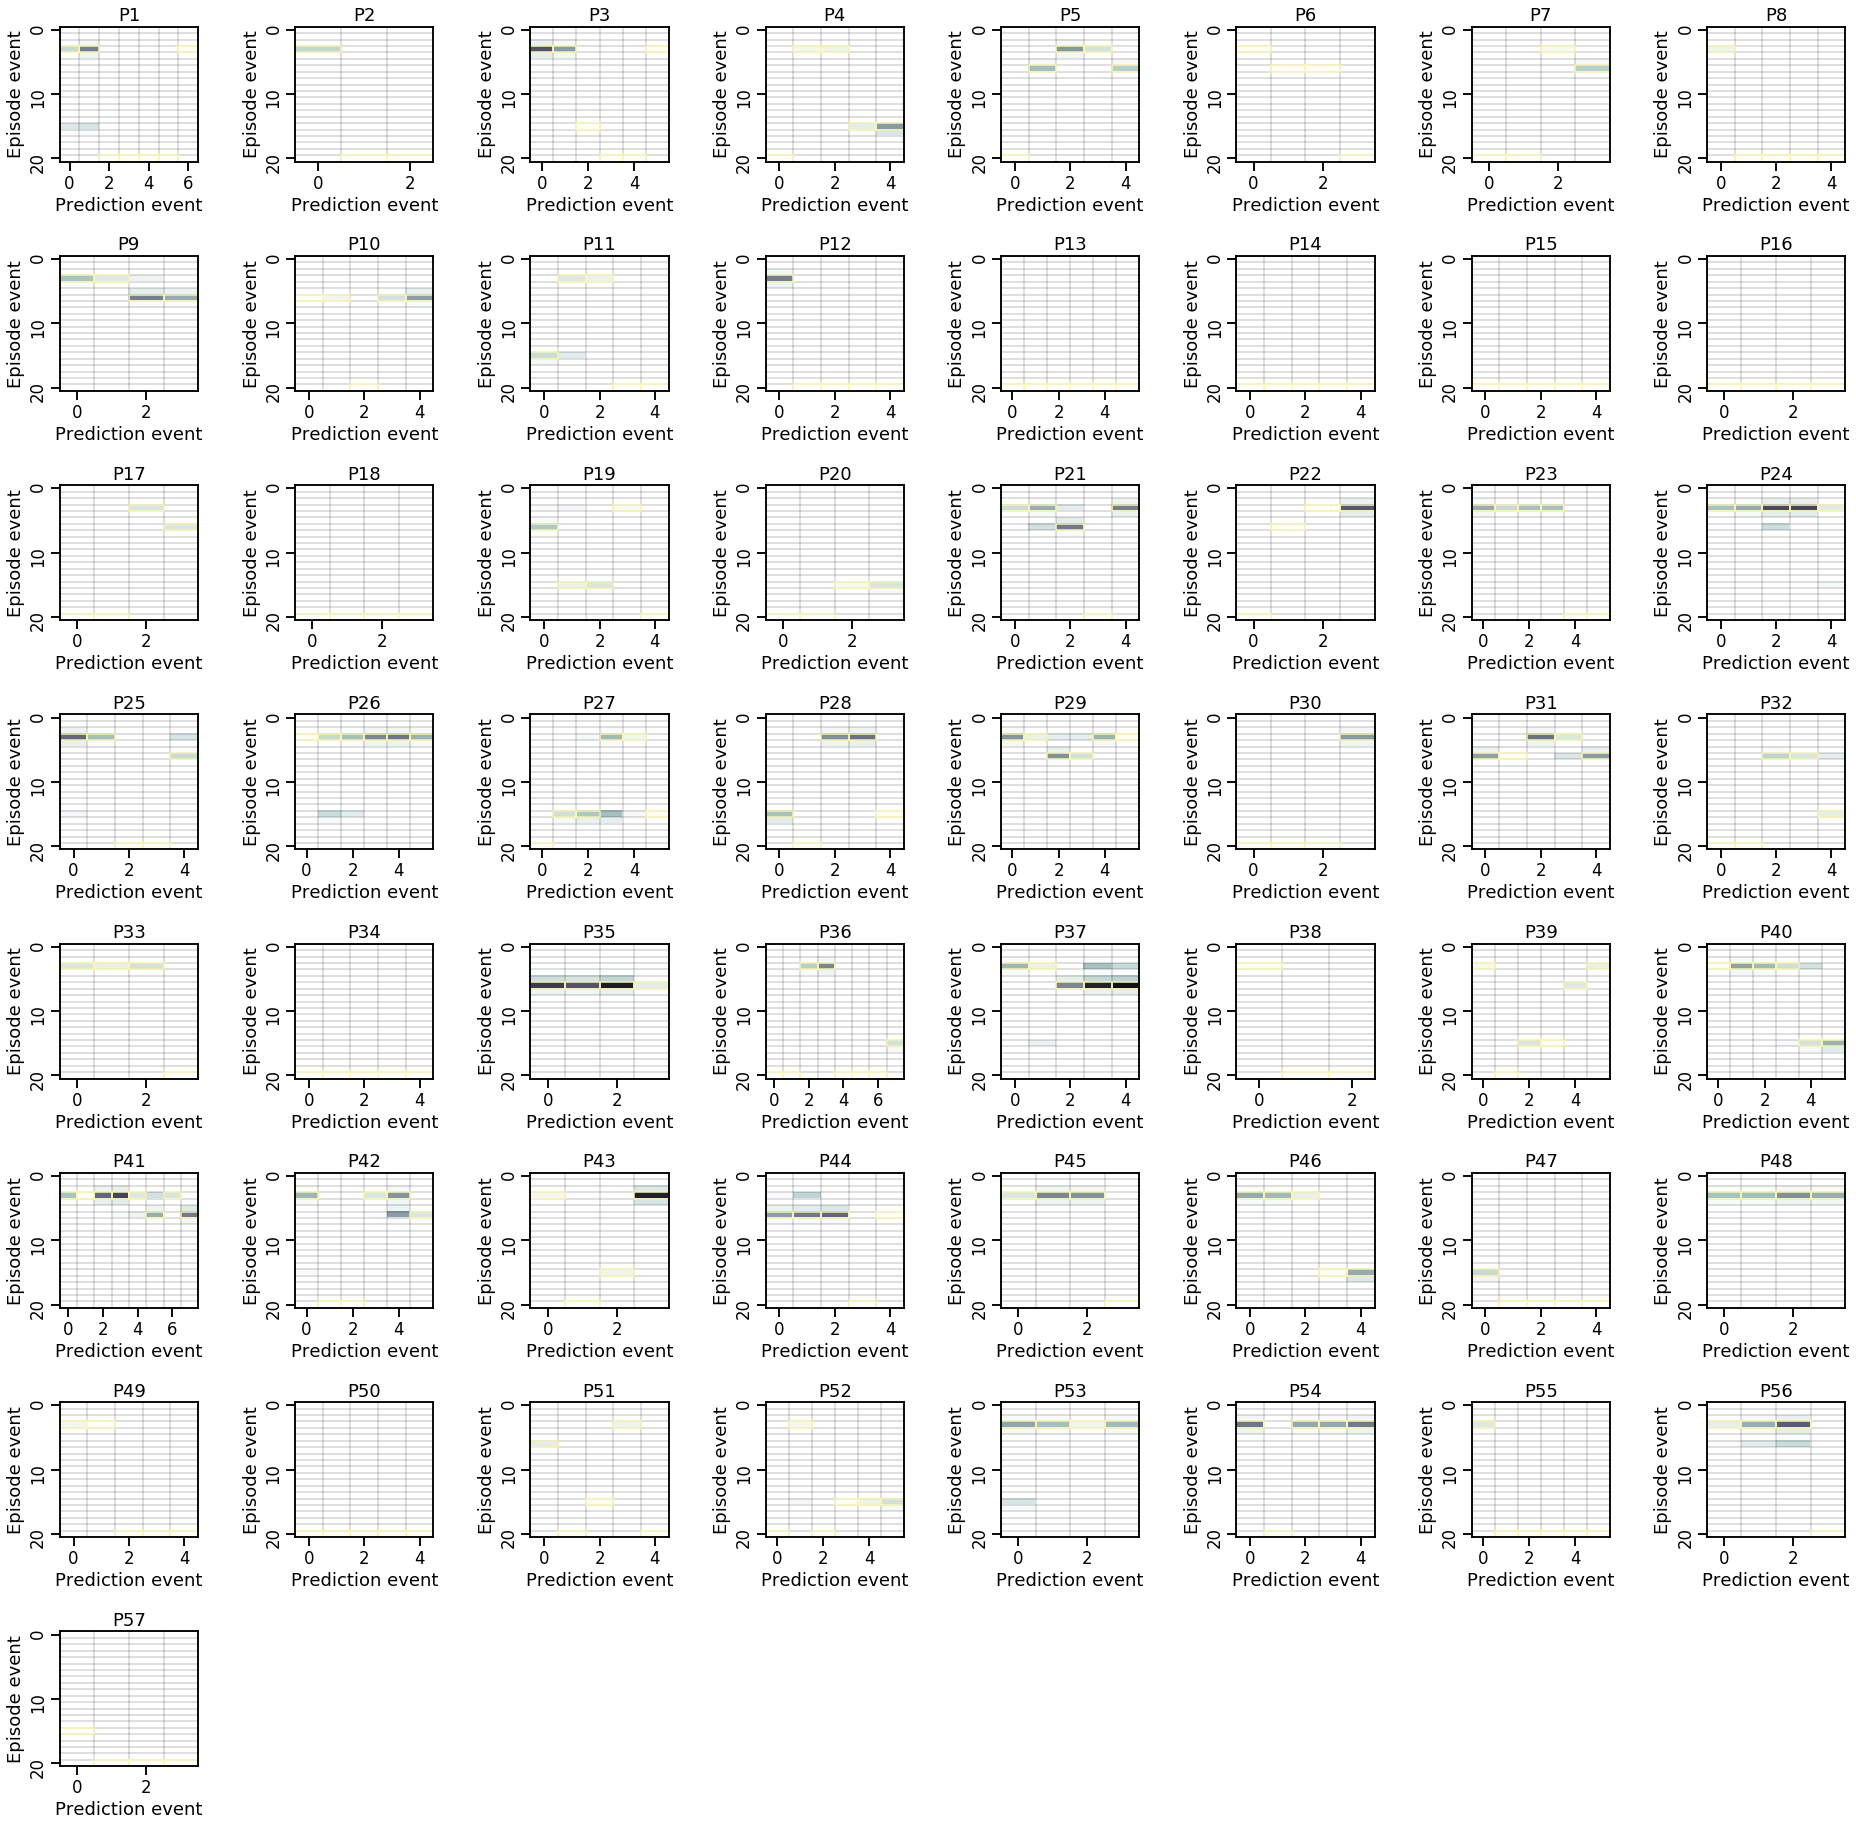

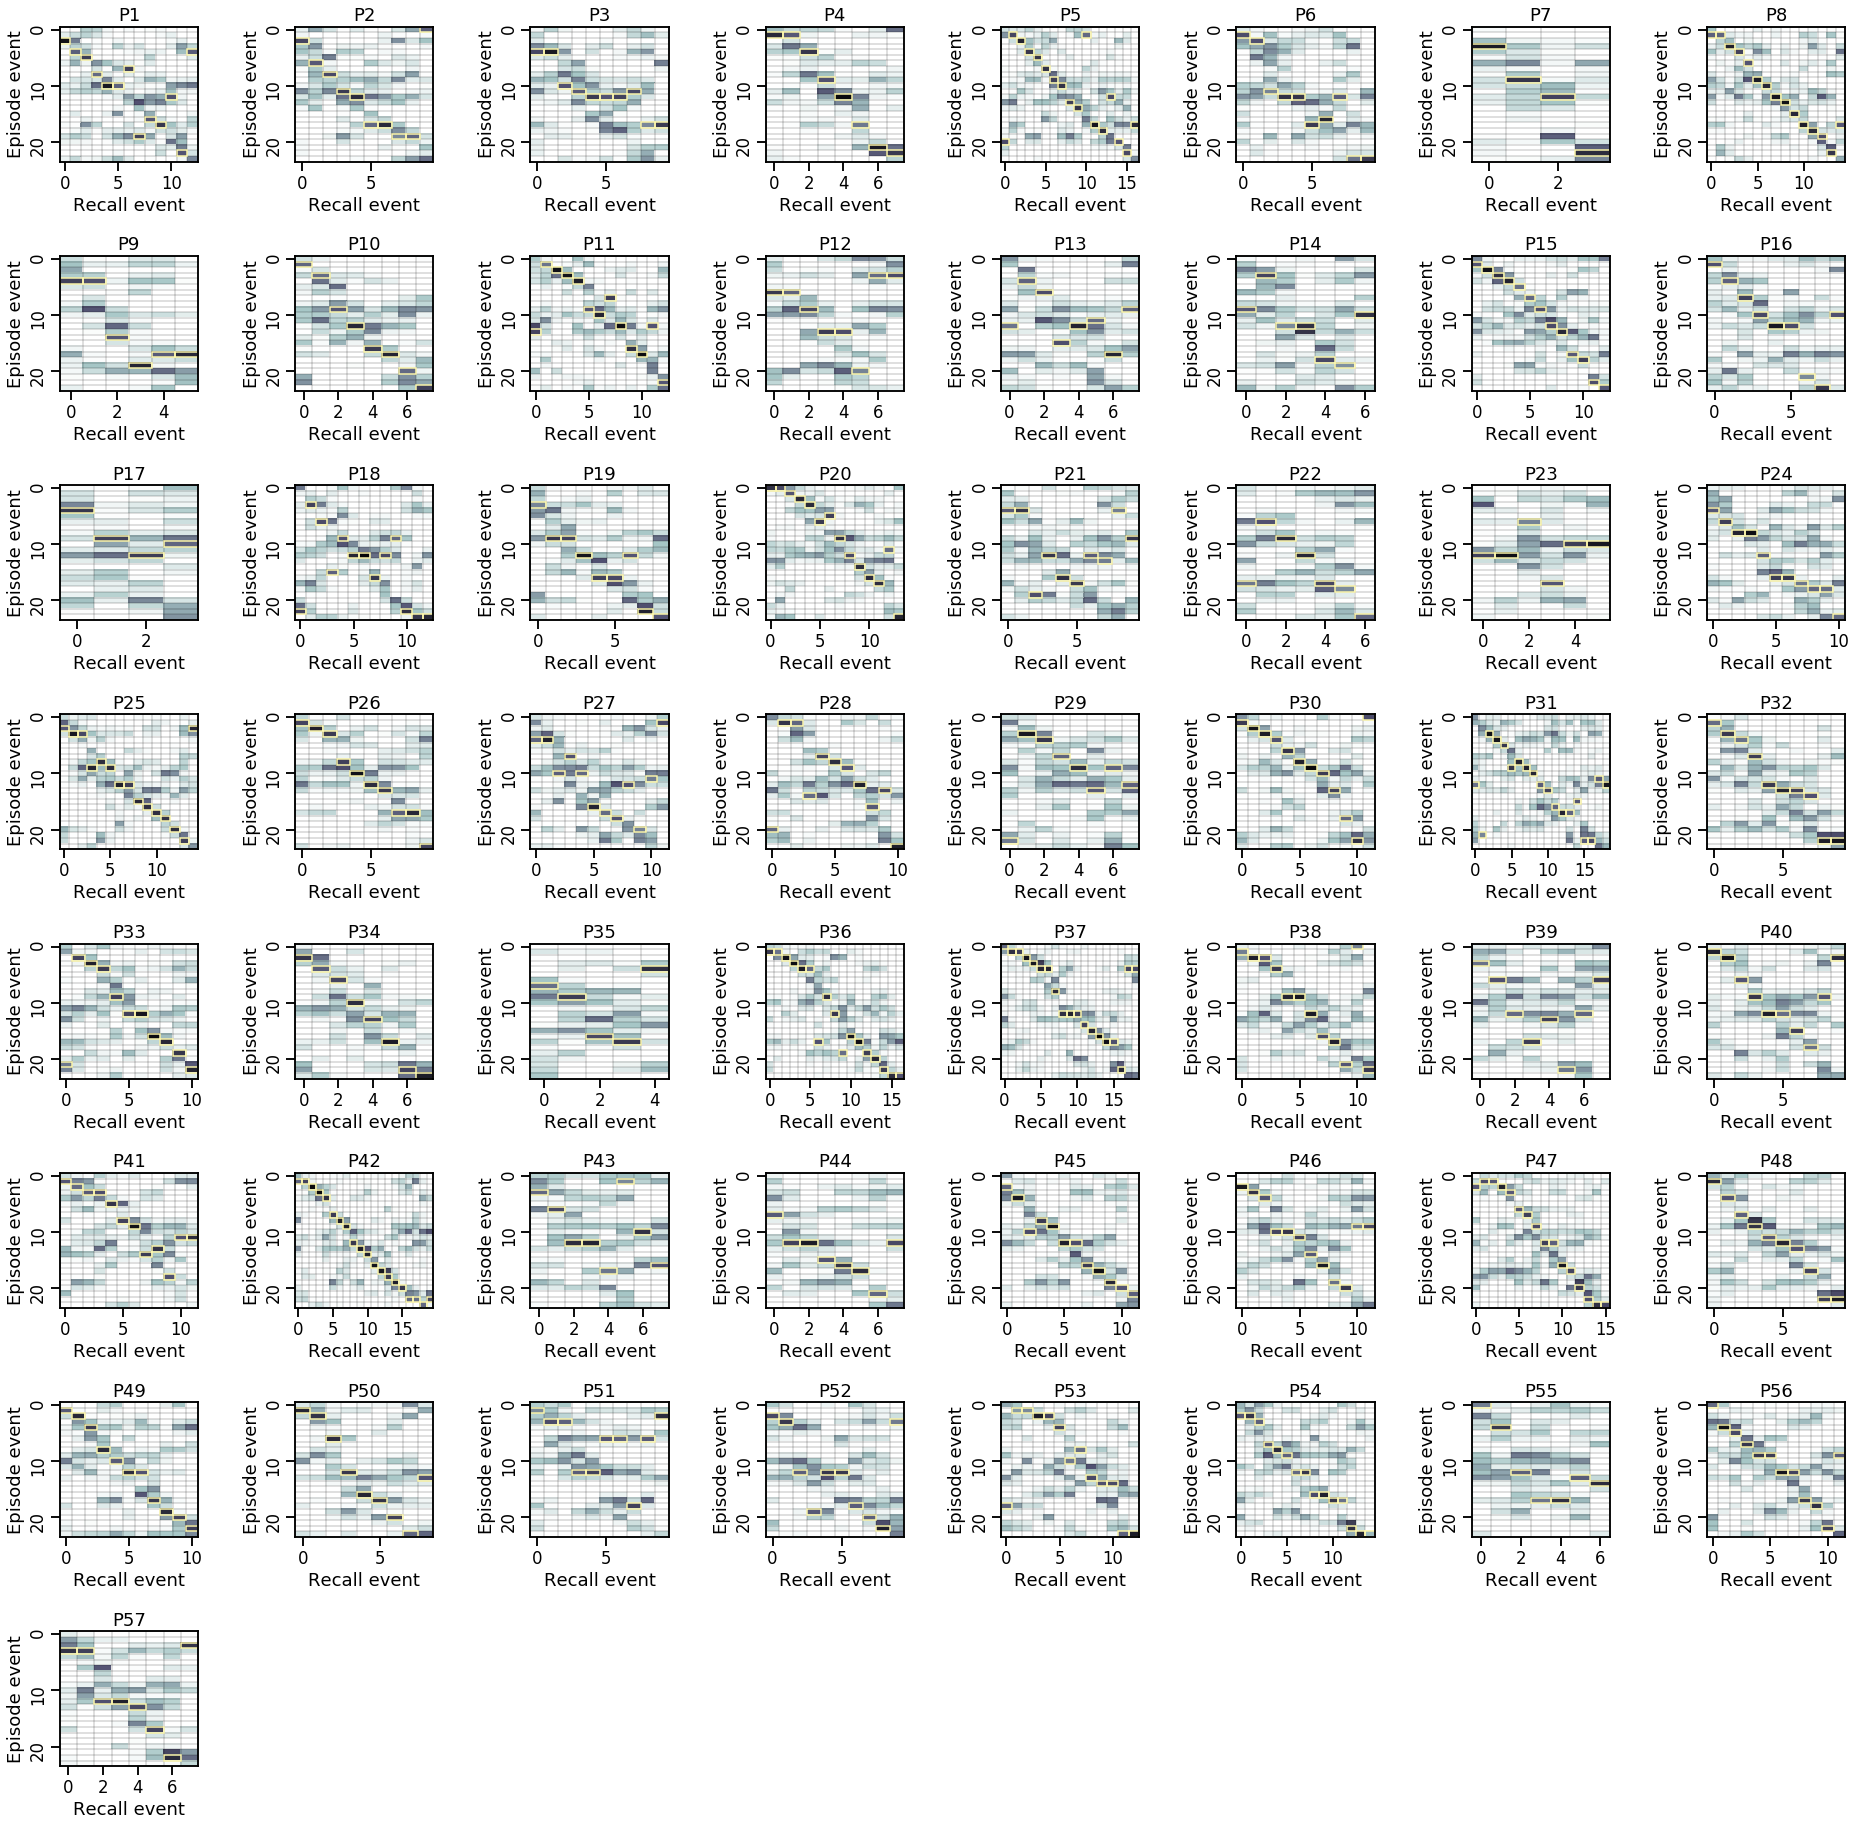

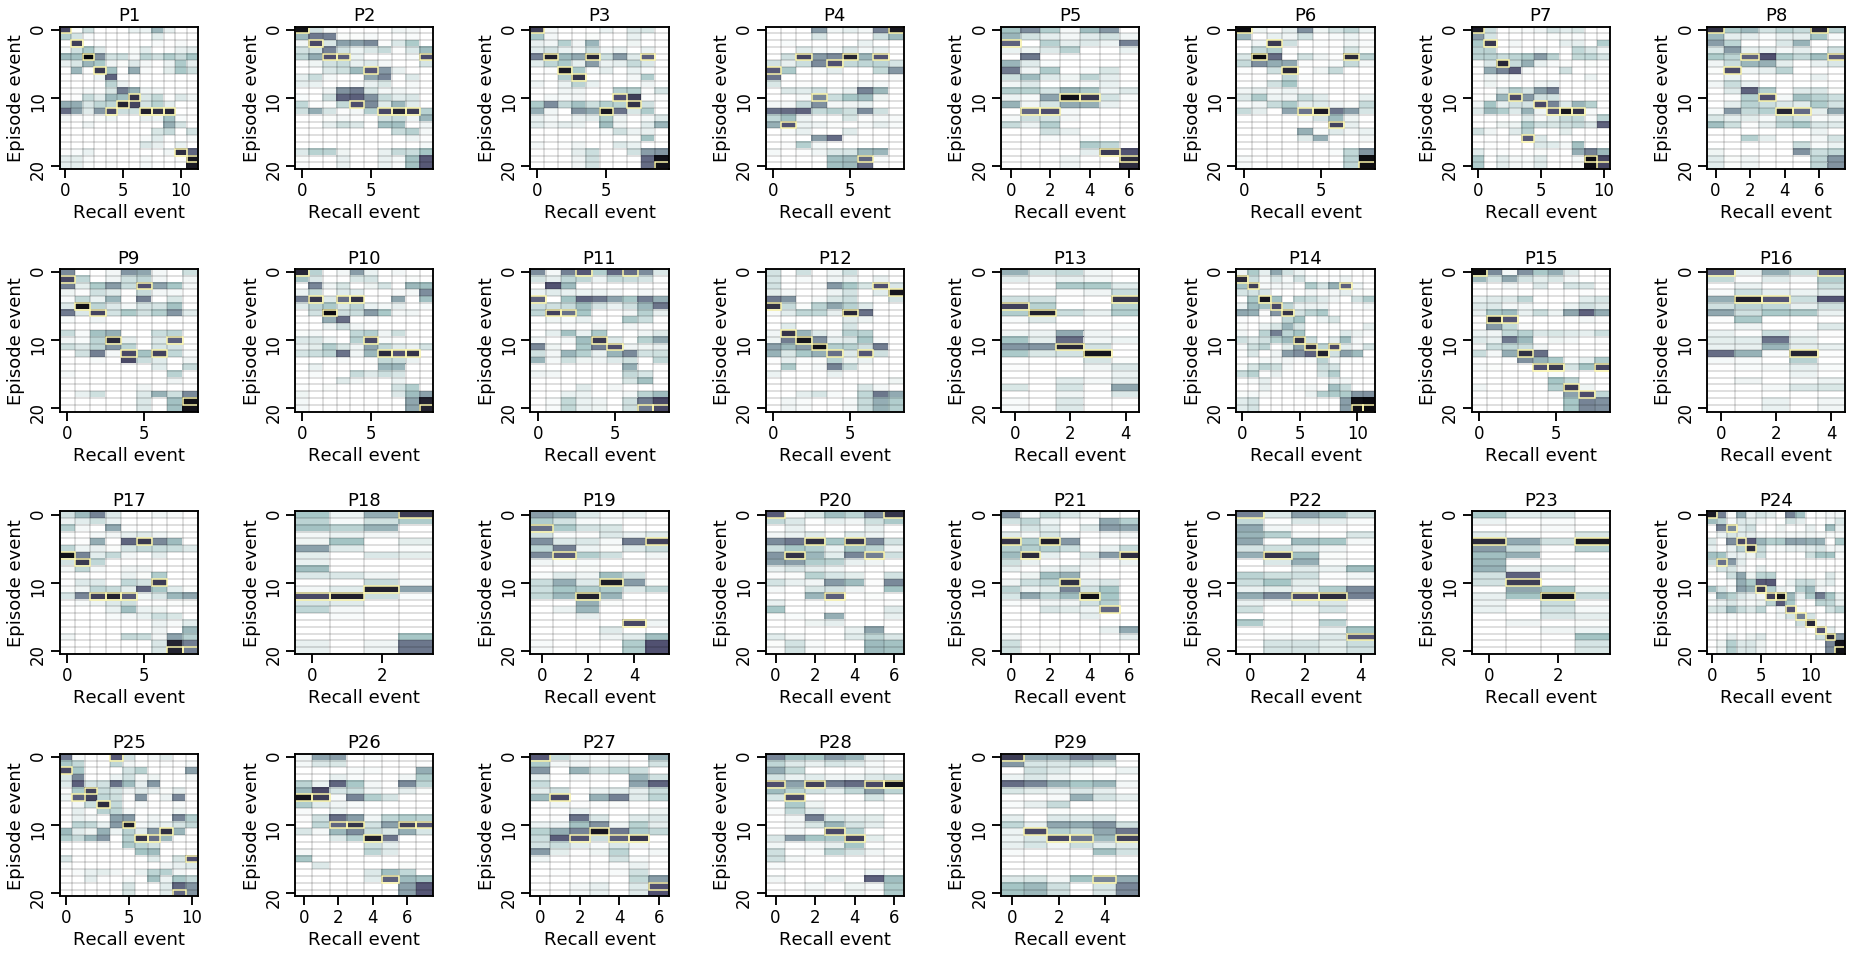

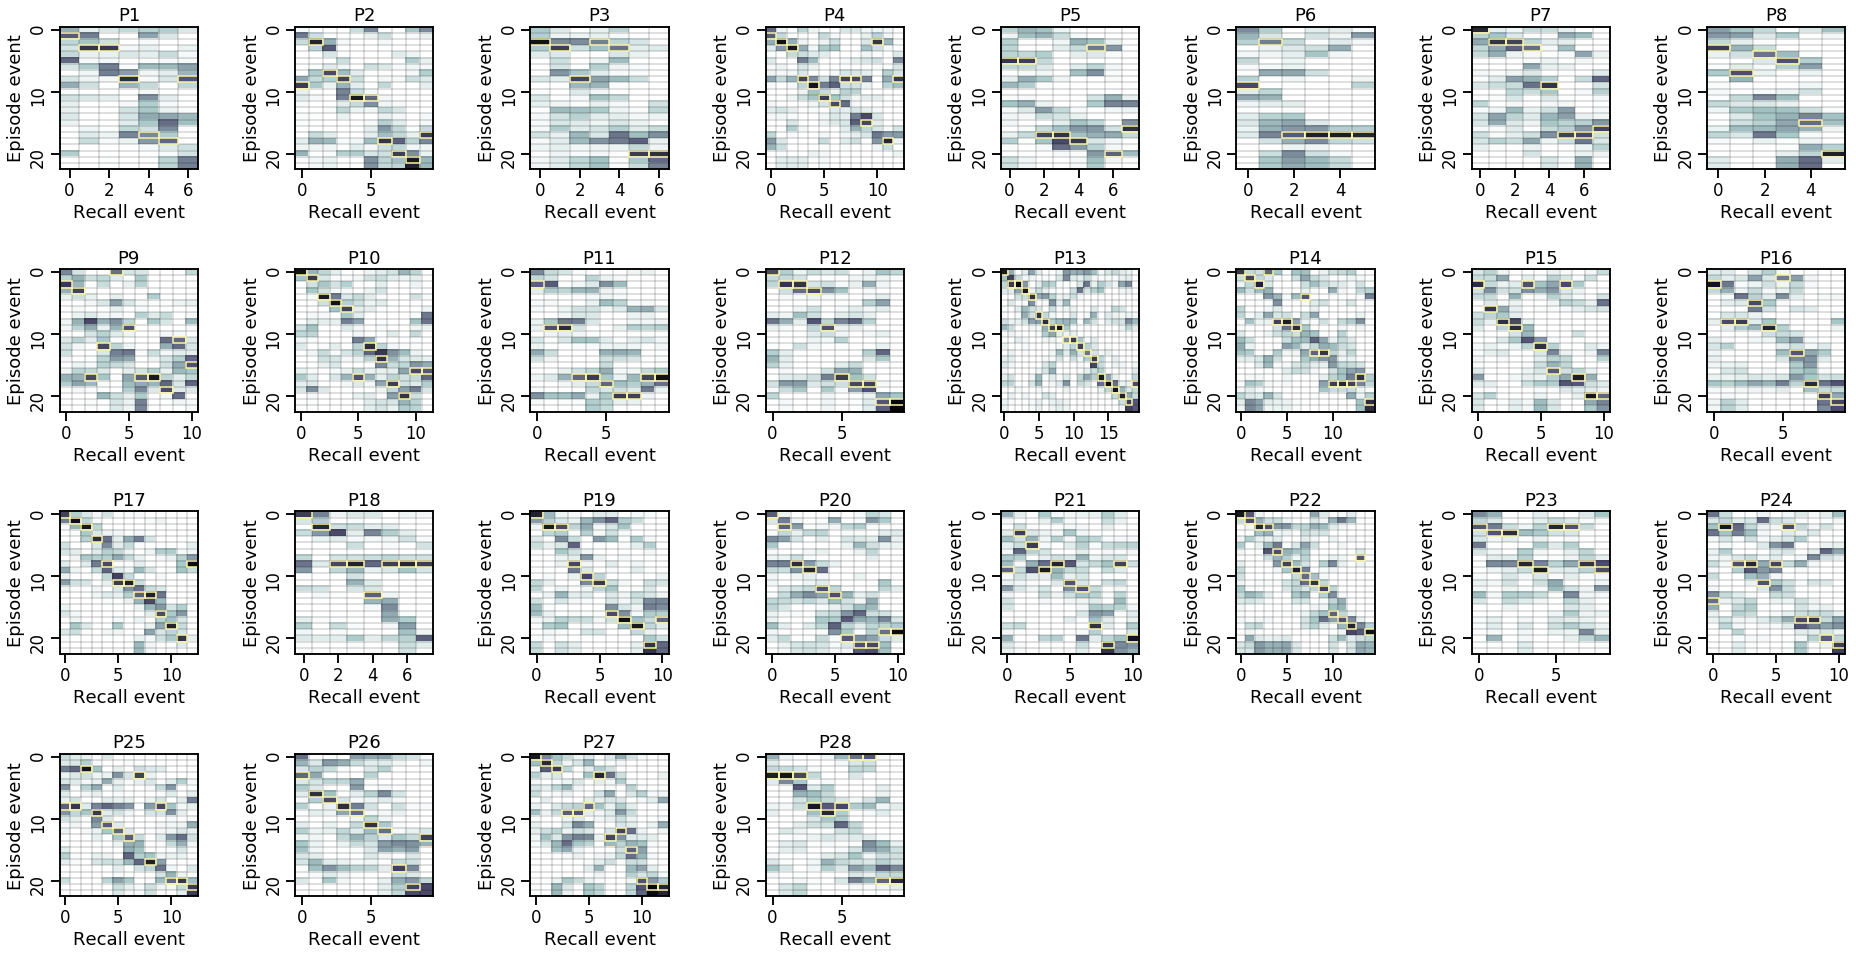

In [7]:
for rectype, mm_dict in matchmats.items():
    fig, axarr = plt.subplots(len(mm_dict)//8 + 1, 8)
    fig.set_size_inches(len(axarr[0])*4,len(axarr)*4)
    axarr = axarr.flatten()
    
    # maintain order of participants across figures
    if rectype in ['atlep1', 'prediction']:
        subs = id_maps['session 1']
    elif rectype == 'atlep2':
        subs = id_maps.loc[id_maps.index.str.contains('A'), 'session 2']
    elif rectype == 'arrdev':
        subs = id_maps.loc[id_maps.index.str.contains('B'), 'session 2']
    else:
        subs = id_maps['session 2']
        
    if show_pbar:
        subs = tqdm(subs, desc=rectype, leave=False)
        
    for i, (ax, sub) in enumerate(zip_longest(axarr, subs)):
            
        if not sub:
            ax.axis('off')
            continue
            
        matchmat = mm_dict[sub]
        rt = rectype.capitalize() if rectype == 'prediction' else 'Recall'
        
        if matchmat.shape[1] > 25:
            xtix = 10
        elif matchmat.shape[1] < 9:
            xtix = 2
        else:
            xtix = 5
            
        data = pd.DataFrame(matchmat)
        a = sns.heatmap(data, cmap=cmap, xticklabels=xtix, yticklabels=10, vmin=0, vmax=1, ax=ax, cbar=False)
        a.set_xlabel(f'{rt} event')
        a.set_ylabel('Episode event')
        a.set_title(f'P{i+1}')

        for _, spine in a.spines.items():
            spine.set_visible(True)

        a.hlines(list(range(matchmat.shape[0])), *a.get_xlim(), linewidth=.25)
        a.vlines(list(range(matchmat.shape[1])), *a.get_ylim(), linewidth=.25)

        bounds = np.argmax(matchmat, axis=0)
        for j in range(len(bounds)):
            rect = patches.Rectangle((j,bounds[j]), 1, 1, linewidth=1.5, edgecolor='#FFF9AE',facecolor='none', zorder=2)
            a.add_patch(rect)
            
    plt.subplots_adjust(hspace=.7, wspace=.7)
    plt.savefig(opj(matchmats_dir, f'matchmats-{rectype}.pdf'))
    plt.show()